In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df=pd.read_csv("indian_roads_dataset.csv")
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [7]:

df.isnull().sum()

accident_id              0
city                     0
state                    0
latitude                 0
longitude                0
date                     0
time                     0
hour                     0
day_of_week              0
is_weekend               0
road_type                0
lanes                    0
traffic_signal           0
weather                  0
visibility               0
temperature              0
traffic_density          0
cause                    0
accident_severity        0
vehicles_involved        0
casualties               0
is_peak_hour             0
festival             19885
risk_score               0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   accident_id        20000 non-null  int64  
 1   city               20000 non-null  object 
 2   state              20000 non-null  object 
 3   latitude           20000 non-null  float64
 4   longitude          20000 non-null  float64
 5   date               20000 non-null  object 
 6   time               20000 non-null  object 
 7   hour               20000 non-null  int64  
 8   day_of_week        20000 non-null  object 
 9   is_weekend         20000 non-null  int64  
 10  road_type          20000 non-null  object 
 11  lanes              20000 non-null  int64  
 12  traffic_signal     20000 non-null  int64  
 13  weather            20000 non-null  object 
 14  visibility         20000 non-null  object 
 15  temperature        20000 non-null  int64  
 16  traffic_density    200

In [14]:
df.tail()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
19995,19995,Bangalore,Karnataka,13.092276,77.599571,2022-09-29,3:00,3,Thursday,0,...,high,31,low,distraction,minor,3,2,0,NaN,0.10
19996,19996,Chennai,Tamil Nadu,13.172928,80.157062,2023-11-25,1:00,1,Saturday,1,...,high,20,low,distraction,major,4,2,0,NaN,0.10
19997,19997,Chennai,Tamil Nadu,12.997170,80.150724,2022-06-18,15:00,15,Saturday,1,...,high,22,low,weather,minor,3,3,0,NaN,0.10
19998,19998,Kolkata,West Bengal,22.454882,88.322213,2023-03-12,4:00,4,Sunday,1,...,high,33,low,poor road,minor,1,0,0,NaN,0.10
19999,19999,Delhi,Delhi,28.510266,77.065301,2024-07-05,23:00,23,Friday,0,...,low,39,high,overspeeding,minor,4,2,0,NaN,0.65


In [15]:
df.shape

(20000, 24)

In [16]:
df.describe()

,accident_id,latitude,longitude,hour,is_weekend,lanes,traffic_signal,temperature,vehicles_involved,casualties,is_peak_hour,risk_score
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,9999.500000,20.389207,78.173330,11.487200,0.286150,3.493950,0.499850,27.579600,2.992000,1.726450,0.247400,0.437585
std,5773.647028,6.165791,4.485967,6.945563,0.451972,1.705406,0.500012,7.454746,1.415534,1.489104,0.431512,0.218130
min,0.000000,12.800172,72.700017,0.000000,0.000000,1.000000,0.000000,15.000000,1.000000,0.000000,0.000000,0.100000
25%,4999.750000,13.198653,73.997979,5.000000,0.000000,2.000000,0.000000,21.000000,2.000000,1.000000,0.000000,0.250000
50%,9999.500000,18.812008,77.297000,12.000000,0.000000,4.000000,0.000000,28.000000,3.000000,1.000000,0.000000,0.450000
75%,14999.250000,28.402467,80.111089,18.000000,1.000000,5.000000,1.000000,34.000000,4.000000,3.000000,0.000000,0.600000
max,19999.000000,30.799960,88.499861,23.000000,1.000000,6.000000,1.000000,40.000000,5.000000,5.000000,1.000000,1.000000


In [19]:
df.duplicated().sum()

np.int64(0)

In [21]:
df['city'].fillna(df['city'].mode()[0], inplace=True)

C:\Users\23\AppData\Local\Temp\19\ipykernel_35280\3130792203.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['city'].fillna(df['city'].mode()[0], inplace=True)


In [31]:
df['date']=pd.to_datetime(df['date'])
df['hour']=df['hour'].astype(int)
df.head()

,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,road_type,...,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,highway,...,low,32,high,weather,fatal,2,2,0,NaN,0.85
1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,urban,...,high,34,low,weather,major,4,3,0,NaN,0.10
2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,urban,...,low,21,medium,weather,minor,1,1,0,NaN,0.45
3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,urban,...,low,30,high,distraction,minor,5,2,0,NaN,0.65
4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,highway,...,high,24,low,distraction,minor,2,1,0,NaN,0.10


In [34]:
df['year']= df['date'].dt.year
df.head()

,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,road_type,...,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,year
0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,highway,...,32,high,weather,fatal,2,2,0,NaN,0.85,2023
1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,urban,...,34,low,weather,major,4,3,0,NaN,0.10,2023
2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,urban,...,21,medium,weather,minor,1,1,0,NaN,0.45,2024
3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,urban,...,30,high,distraction,minor,5,2,0,NaN,0.65,2025
4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,highway,...,24,low,distraction,minor,2,1,0,NaN,0.10,2024


In [35]:
print("Mean:",df['hour'].mean())
df.head()

Mean: 11.4872


,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,road_type,...,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,year
0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,highway,...,32,high,weather,fatal,2,2,0,NaN,0.85,2023
1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,urban,...,34,low,weather,major,4,3,0,NaN,0.10,2023
2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,urban,...,21,medium,weather,minor,1,1,0,NaN,0.45,2024
3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,urban,...,30,high,distraction,minor,5,2,0,NaN,0.65,2025
4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,highway,...,24,low,distraction,minor,2,1,0,NaN,0.10,2024


In [36]:
print("Median:", df['hour'].median())
df.head()

Median: 12.0


,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,road_type,...,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,year
0,Pune,Maharashtra,18.680827,73.930388,2023-10-22,5:00,5,Sunday,1,highway,...,32,high,weather,fatal,2,2,0,NaN,0.85,2023
1,Mumbai,Maharashtra,18.817732,72.790846,2023-05-21,4:00,4,Sunday,1,urban,...,34,low,weather,major,4,3,0,NaN,0.10,2023
2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,urban,...,21,medium,weather,minor,1,1,0,NaN,0.45,2024
3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,urban,...,30,high,distraction,minor,5,2,0,NaN,0.65,2025
4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,highway,...,24,low,distraction,minor,2,1,0,NaN,0.10,2024


In [37]:
print("Mode:", df['hour'].mode()[0])

Mode: 2


In [39]:
df[df['city']=="mumbai"]
df[(df['hour']>10)&(df['hour']<18)]

,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,road_type,...,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,year
2,Mumbai,Maharashtra,19.096889,72.819424,2024-07-10,13:00,13,Wednesday,0,urban,...,21,medium,weather,minor,1,1,0,NaN,0.45,2024
3,Chandigarh,Punjab,30.787805,76.847507,2025-03-30,11:00,11,Sunday,1,urban,...,30,high,distraction,minor,5,2,0,NaN,0.65,2025
4,Chennai,Tamil Nadu,12.965155,80.283313,2024-01-25,16:00,16,Thursday,0,highway,...,24,low,distraction,minor,2,1,0,NaN,0.10,2024
7,Chandigarh,Punjab,30.786617,76.733947,2023-05-07,14:00,14,Sunday,1,urban,...,25,low,weather,major,3,0,0,NaN,0.10,2023
10,Chandigarh,Punjab,30.651926,76.876892,2022-03-23,13:00,13,Wednesday,0,highway,...,34,medium,poor road,minor,3,3,0,NaN,0.45,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19977,Delhi,Delhi,28.798462,77.242472,2023-05-23,14:00,14,Tuesday,0,urban,...,38,medium,weather,major,1,1,0,NaN,0.10,2023
19982,Pune,Maharashtra,18.626351,73.703876,2024-01-31,13:00,13,Wednesday,0,rural,...,18,medium,distraction,major,3,1,0,NaN,0.45,2024
19983,Bangalore,Karnataka,12.950764,77.619541,2022-01-28,15:00,15,Friday,0,urban,...,38,high,distraction,minor,4,2,0,NaN,0.65,2022
19986,Bangalore,Karnataka,13.081738,77.602311,2022-09-11,15:00,15,Sunday,1,rural,...,39,medium,drunk driving,minor,2,1,0,NaN,0.45,2022


In [41]:
plt.figure()

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='state', ylabel='count'>

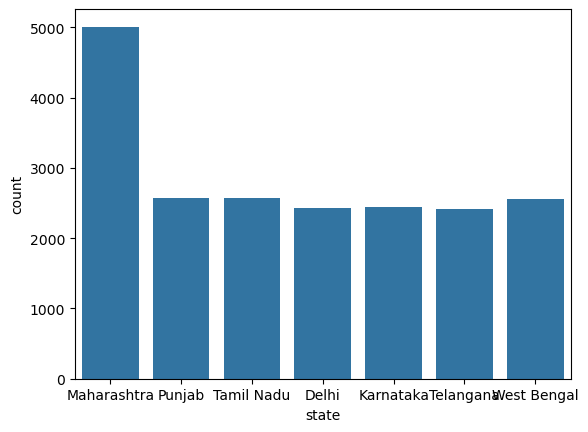

In [42]:
sns.countplot(x='state', data=df)

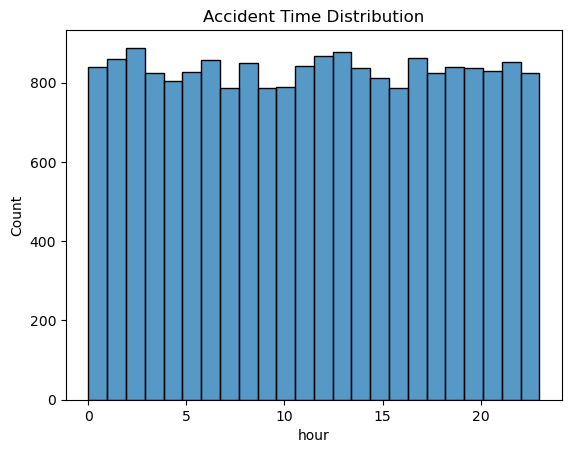

In [46]:
sns.histplot(df['hour'],bins=24)
plt.title("Accident Time Distribution")
plt.show()

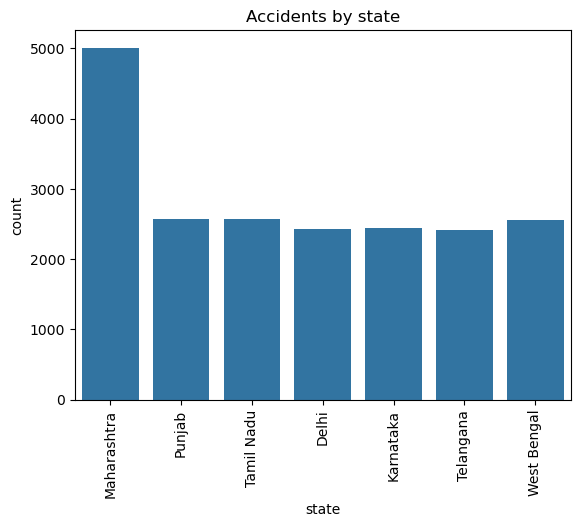

In [51]:
sns.countplot(x='state',data=df)
plt.title("Accidents by state")
plt.xticks(rotation=90)
plt.xlabel("state")
plt.ylabel("count")
plt.show()

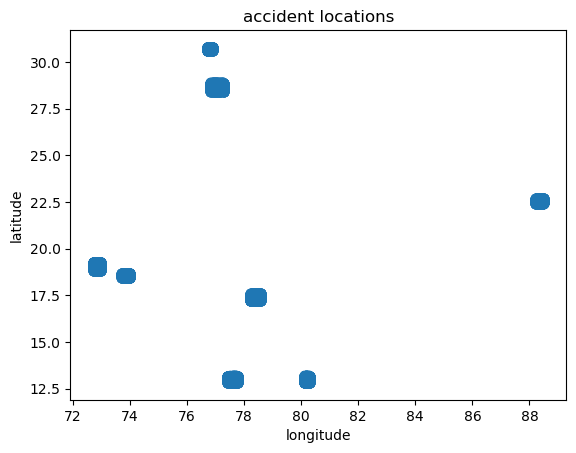

In [53]:
plt.scatter(df['longitude'],df['latitude'])
plt.title("accident locations")
plt.xlabel("longitude")
plt.ylabel("latitude")
plt.show()

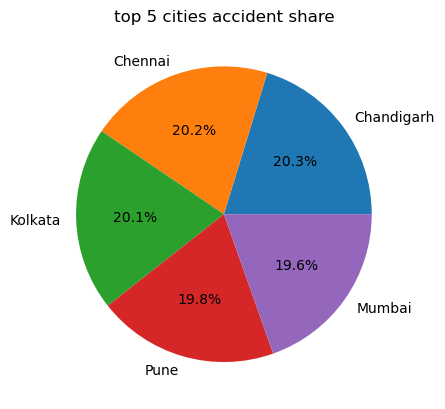

In [54]:
city_data=df['city'].value_counts().head(5)
plt.figure()
city_data.plot.pie(autopct='%1.1f%%')
plt.title("top 5 cities accident share")
plt.ylabel("")
plt.show()

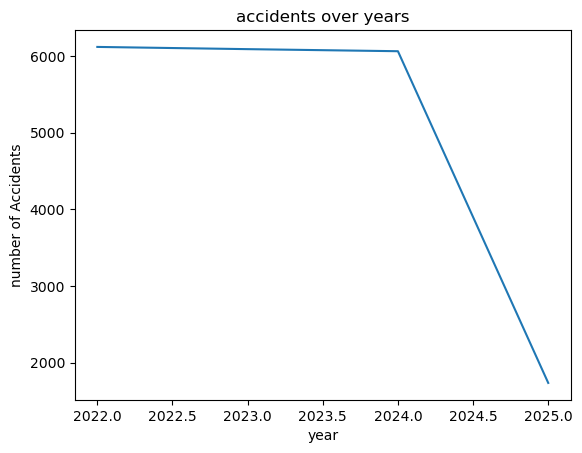

In [56]:
year_data=df['year'].value_counts().sort_index()
plt.figure()
plt.plot(year_data.index, year_data.values)
plt.title("accidents over years")
plt.xlabel("year")
plt.ylabel("number of Accidents")
plt.show()

In [57]:
pivot_state= pd.pivot_table(df, index='state',values='hour', aggfunc='count')
